In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(),"..")))

from modules.seismo_response.class_parameters import (
    HH_Param_Multi_Layer,
    GQH_Param_Multi_Layer,
    MKZ_Param_Multi_Layer,
    HH_Param,
    MKZ_Param,
    GQH_Param,
)

from modules.seismo_response.class_ground_motion import Ground_Motion
from modules.seismo_response.class_Vs_profile import Vs_Profile

from modules.seismo_response.class_simulation import Nonlinear_Simulation

from libs.config.config_variables import STORAGE_DIR, UNIT_GROUND_MOTION

In [2]:
session = "sesion_20260223_103200_ew"

input_dir = STORAGE_DIR / "raw_data" / session
output_dir = STORAGE_DIR / "output_data" / session

accel_file = input_dir / "input_accel.txt"
vs_file = input_dir / "vs_profile.txt"
dynamic_curvas_file = input_dir / "dynamic_curves.txt"

In [3]:
sismo_prueba = Ground_Motion(data = str(accel_file), unit=UNIT_GROUND_MOTION)
perfil_prueba = Vs_Profile(data=str(vs_file))

In [ ]:
# Data del HH
dict_parameters_hh_est_1 = {
    "gamma_t":0.00076,
    "a":100.0,
    "gamma_ref":0.000314,
    "beta":1.0,
    "s":0.919,
    "Gmax":26925687.444,
    "mu":0.20624534,
    "Tmax":27822.476,
    "d":0.908793,
    }

dict_parameters_hh_est_2 = {
    "gamma_t":0.00076,
    "a":100.0,
    "gamma_ref":0.000314,
    "beta":1.0,
    "s":0.919,
    "Gmax":26925687.444,
    "mu":0.20624534,
    "Tmax":27822.476,
    "d":0.908793,
    }

# Data del MKZ
dict_parameters_mkz_est_1 = {
    "gamma_ref":0.000408,
    "s":0.838,
    "beta":1.73,
    "Gmax":14863.0,
    }

dict_parameters_mkz_est_2 = {
    "gamma_ref":0.000408,
    "s":0.838,
    "beta":1.73,
    "Gmax":14863.0,
    }
# Data del GQH
dict_parameters_gqh_est_1 = {
    "gamma_ref":0.021,
    "theta_1":0.1,
    "theta_2":0.3,
    "theta_3":1.0,
    "theta_4":1.0,
    "theta_5":4.0,
    "Gmax":14863.0,
    }

dict_parameters_gqh_est_2 = {
    "gamma_ref":0.022,
    "theta_1":0.2,
    "theta_2":0.4,
    "theta_3":1.0,
    "theta_4":1.0,
    "theta_5":3.0,
    "Gmax":14863.0,
    }

In [5]:
# Curvas con el modelo HH
hh_curva_est1 = HH_Param(param_dict=dict_parameters_hh_est_1)
hh_curva_est2 = HH_Param(param_dict=dict_parameters_hh_est_2)
# Curvas con el modelo MKZ
mkz_curva_est1 = MKZ_Param(param_dict=dict_parameters_mkz_est_1)
mkz_curva_est2 = MKZ_Param(param_dict=dict_parameters_mkz_est_2)
# Curvas con el modelo GQH
gqh_curva_est1 = GQH_Param(param_dict=dict_parameters_gqh_est_1)
gqh_curva_est2 = GQH_Param(param_dict=dict_parameters_gqh_est_2)

In [6]:
lista_de_curvas_hh = [hh_curva_est1, hh_curva_est2]
lista_de_curvas_mkz = [mkz_curva_est1, mkz_curva_est2]
lista_de_curvas_gqh = [gqh_curva_est1, gqh_curva_est2]

In [7]:
# curvas_por_estrato = Param_Multi_Layer(
#     list_of_param_data=lista_de_curvas_gqh,
#     element_class=GQH_Param
#     )

# curvas_por_estrato = Param_Multi_Layer(
#     list_of_param_data=lista_de_curvas_mkz,
#     element_class=MKZ_Param
#     )

In [8]:
curvas_por_estrato_hh = HH_Param_Multi_Layer(
    lista_de_curvas_hh
    )

curvas_por_estrato_mkz = MKZ_Param_Multi_Layer(
    lista_de_curvas_mkz
    )

curvas_por_estrato_gqh = GQH_Param_Multi_Layer(
    lista_de_curvas_gqh
    )

In [9]:
# data = curvas_por_estrato_mkz.construct_curves()
# data[0].plot()
# data_layer = curvas_por_estrato_gqh.construct_curves()
# data_layer[0].plot()
#curvas_por_estrato_mkz.param_list
# mgc = curvas_por_estrato_hh.construct_curves(curve_type="ggmax")
# mgc[0].plot()

## Simulación

2026-02-27 01:25:49,366 [INFO] modules.seismo_response.class_simulation: Simulación no lineal...
2026-02-27 01:25:54,382 [INFO] modules.seismo_response.class_simulation: Simulación finalizada.


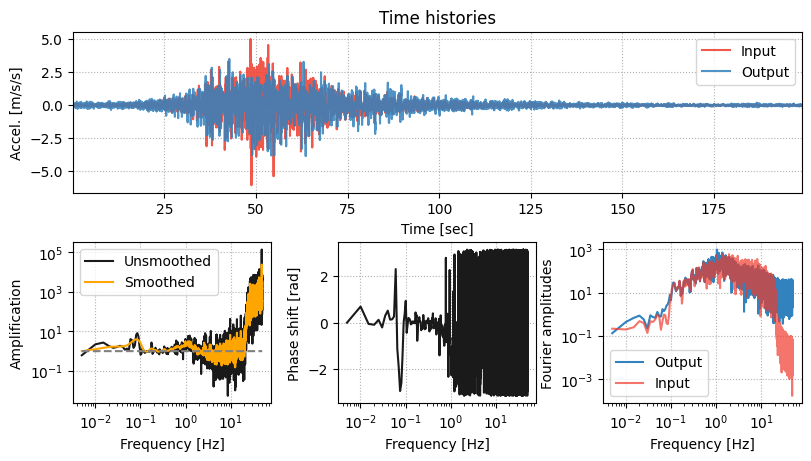

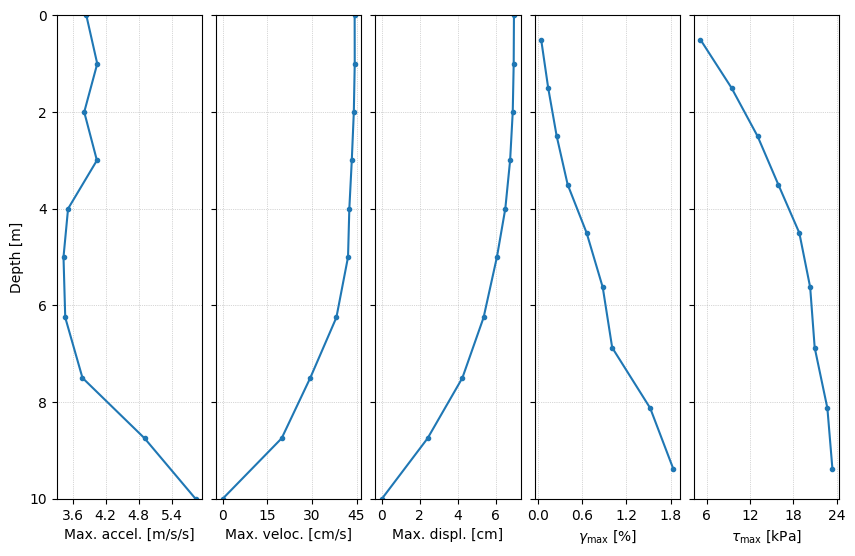

In [10]:
simulacion_hh = Nonlinear_Simulation(
    soil_profile=perfil_prueba,
    input_motion=sismo_prueba,
    G_param=curvas_por_estrato_hh,
    xi_param=curvas_por_estrato_hh,
)
simulacion_hh.run(show_fig=True)

In [18]:
mgc, mdc = curvas_por_estrato_hh.construct_curves()

(<Figure size 300x300 with 1 Axes>,
 <Axes: xlabel='Strain [%]', ylabel='G/Gmax'>)

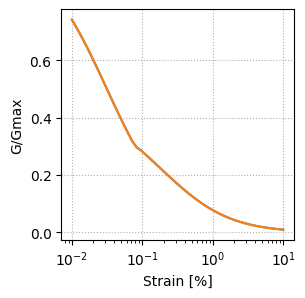

In [19]:
mgc.plot()

In [13]:
simulacion_mkz = Nonlinear_Simulation(
    soil_profile=perfil_prueba,
    input_motion=sismo_prueba,
    G_param=curvas_por_estrato_mkz,
    xi_param=curvas_por_estrato_mkz,
)
simulacion_mkz.run(show_fig=True)

2026-02-27 01:26:37,912 [INFO] modules.seismo_response.class_simulation: Simulación no lineal...
2026-02-27 01:26:38,011 [INFO] modules.seismo_response.class_simulation: Simulación finalizada.


ValueError: zero-size array to reduction operation maximum which has no identity

In [12]:
simulacion_gqh = Nonlinear_Simulation(
    soil_profile=perfil_prueba,
    input_motion=sismo_prueba,
    G_param=curvas_por_estrato_gqh,
    xi_param=curvas_por_estrato_gqh,
)
simulacion_gqh.run(show_fig=True)

2026-02-27 01:26:02,272 [INFO] modules.seismo_response.class_simulation: Simulación no lineal...
2026-02-27 01:26:02,369 [INFO] modules.seismo_response.class_simulation: Simulación finalizada.
c:\Users\william.ortiz\OneDrive - ANDDES ASOCIADOS SAC\09_Otros\Escritorio\Proyectos GITLAB\PRISMO_GITLAB\prismo\modules\seismo_response\class_simulation.py:712: UserWarning: genfromtxt: Empty input file: "node_depth.dat"
  layer_boundary_depth = np.genfromtxt("node_depth.dat").T
c:\Users\william.ortiz\OneDrive - ANDDES ASOCIADOS SAC\09_Otros\Escritorio\Proyectos GITLAB\PRISMO_GITLAB\prismo\modules\seismo_response\class_simulation.py:713: UserWarning: genfromtxt: Empty input file: "layer_depth.dat"
  layer_midpoint_depth = np.genfromtxt("layer_depth.dat").T
c:\Users\william.ortiz\OneDrive - ANDDES ASOCIADOS SAC\09_Otros\Escritorio\Proyectos GITLAB\PRISMO_GITLAB\prismo\modules\seismo_response\class_simulation.py:714: UserWarning: genfromtxt: Empty input file: "out_a.dat"
  out_a = np.genfromtxt("o

ValueError: zero-size array to reduction operation maximum which has no identity

In [ ]:
# mkz_curvas = MKZ_Param(param_dict=dict_parameters)
# mkz_curvas.get_GGmax()
# parametros = Parameter(param_dict=dict_parameters, allowable_keys=aloow)